<a href="https://colab.research.google.com/github/IrineuBovoJunior398/Pos-em-IA/blob/main/C%C3%B3pia_de_ADALINE_EXERCICIO_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


ADALINE - Previsão de Preço de Casa
Época 0: MSE = 10.971191
Época 10: MSE = 340093.603906
Época 20: MSE = 10577850531.777700
Época 30: MSE = 329000404845229.312500
Época 40: MSE = 10232822449465542656.000000
Época 50: MSE = 318269077302638922432512.000000
Época 60: MSE = 9899048485138516378608730112.000000
Época 70: MSE = 307887783951892586715024105406464.000000
Época 80: MSE = 9576161552206075958342812114691817472.000000
Época 90: MSE = 297845107385873271399360927952551238696960.000000

Pesos aprendidos: [-1.19998908e+22 -2.23452157e+22]
Bias aprendido: -6.977882010309921e+21

Predições para teste (em centenas de milhares):
Amostra 1: $-7844077943657691852308480.0k
Amostra 2: $-11708947255853906235752448.0k


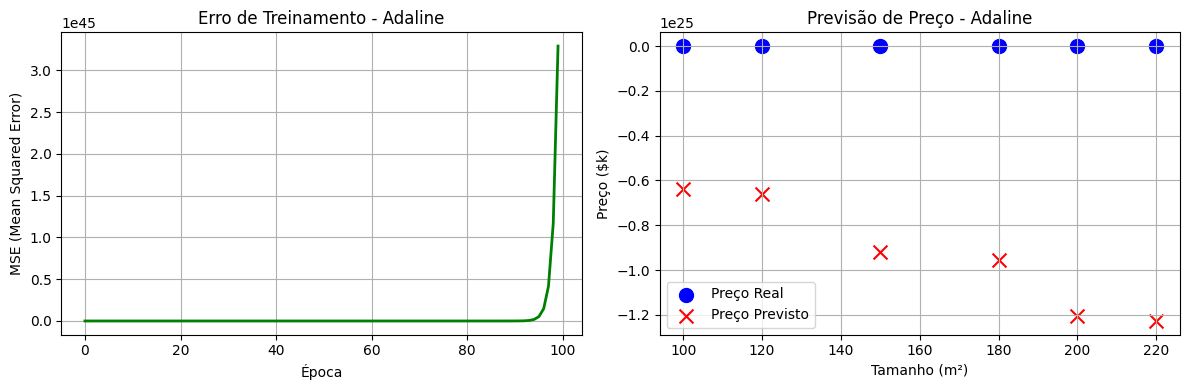

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class Adaline:
    def __init__(self, taxa_aprendizado=0.01, epocas=100):
        self.taxa_aprendizado = taxa_aprendizado
        self.epocas = epocas
        self.pesos = None
        self.bias = None
        self.erros_mse = []

    def funcao_ativacao(self, x):
        """Função identidade: retorna x sem transformação"""
        return x

    def treinar(self, X, y):
        """
        X: matriz de entradas (n_amostras, n_features)
        y: vetor de valores alvo (contínuos)
        """
        n_amostras, n_features = X.shape

        # Inicializa pesos aleatoriamente
        self.pesos = np.random.randn(n_features) * 0.01
        self.bias = 0

        for epoca in range(self.epocas):
            # Calcula predições para todas as amostras
            soma = np.dot(X, self.pesos) + self.bias
            predicoes = self.funcao_ativacao(soma)

            # Calcula erro
            erros = y - predicoes

            # Calcula MSE (Mean Squared Error)
            mse = np.mean(erros ** 2)
            self.erros_mse.append(mse)

            # Calcula gradientes
            gradiente_pesos = -2 * np.dot(X.T, erros) / n_amostras
            gradiente_bias = -2 * np.mean(erros)

            # Atualiza pesos usando gradiente descendente
            self.pesos -= self.taxa_aprendizado * gradiente_pesos
            self.bias -= self.taxa_aprendizado * gradiente_bias

            if epoca % 10 == 0:
                print(f"Época {epoca}: MSE = {mse:.6f}")

        return self.erros_mse

    def prever(self, X):
        """Faz predições para novas amostras"""
        soma = np.dot(X, self.pesos) + self.bias
        return self.funcao_ativacao(soma)


# Exemplo de uso: Prever preço de casa
print("\n" + "=" * 50)
print("ADALINE - Previsão de Preço de Casa")
print("=" * 50)

# Dados: [tamanho em 100m², número de quartos]
X_treino = np.array([
    [1.0, 2],   # 100m², 2 quartos → $200k
    [1.5, 3],   # 150m², 3 quartos → $300k
    [2.0, 4],   # 200m², 4 quartos → $400k
    [1.2, 2],   # 120m², 2 quartos → $240k
    [1.8, 3],   # 180m², 3 quartos → $360k
    [2.2, 4]    # 220m², 4 quartos → $440k
])

# Preços em centenas de milhares
y_treino = np.array([2.0, 3.0, 4.0, 2.4, 3.6, 4.4])

# Cria e treina o Adaline
adaline = Adaline(taxa_aprendizado=0.1, epocas=100)
erros = adaline.treinar(X_treino, y_treino)

print("\nPesos aprendidos:", adaline.pesos)
print("Bias aprendido:", adaline.bias)

# Testa com novas amostras
X_teste = np.array([
    [1.3, 2.5],  # 130m², 2.5 quartos
    [2.1, 3.8]   # 210m², 3.8 quartos
])

predicoes = adaline.prever(X_teste)
print("\nPredições para teste (em centenas de milhares):")
for i, pred in enumerate(predicoes):
    print(f"Amostra {i+1}: ${pred*100:.1f}k")

# Visualiza o treinamento
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(erros, 'g-', linewidth=2)
plt.xlabel('Época')
plt.ylabel('MSE (Mean Squared Error)')
plt.title('Erro de Treinamento - Adaline')
plt.grid(True)

plt.subplot(1, 2, 2)
# Visualiza predições vs reais (usando apenas tamanho para simplificar)
tamanhos = X_treino[:, 0] * 100
plt.scatter(tamanhos, y_treino * 100, c='blue', s=100, label='Preço Real', marker='o')
predicoes_treino = adaline.prever(X_treino)
plt.scatter(tamanhos, predicoes_treino * 100, c='red', s=100, label='Preço Previsto', marker='x')
plt.xlabel('Tamanho (m²)')
plt.ylabel('Preço ($k)')
plt.title('Previsão de Preço - Adaline')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()